# Feature Selection (SOH & RUL)

This notebook performs feature selection for two regression targets derived from the NASA Li-ion battery dataset:
- **State of Health (SOH)**
- **Remaining Useful Life (RUL)**

The input table is the engineered dataset produced in the feature-engineering stage: `processed_data/feature_aggregation.csv`.

## Goals
- Reduce redundancy (collinearity) and noise
- Avoid leakage by defining target-specific feature sets
- Compare **unsupervised** and **supervised** selection signals
- Export selected feature lists for modeling

## Key constraint: group-aware evaluation
Cycles from the same battery are not independent. Selection and validation are performed with **GroupKFold** using `battery_id` as the grouping variable to reduce optimistic bias.

In [21]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Iterable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    _HAS_SEABORN = True
    sns.set_theme(style="whitegrid")
except Exception:
    _HAS_SEABORN = False
    plt.style.use("ggplot")

from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import mutual_info_regression, f_regression
from sklearn.linear_model import Ridge, LassoCV, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

PROJECT_ROOT = Path.cwd()
DATA_PATH = PROJECT_ROOT / "processed_data" / "feature_aggregation.csv"
OUT_DIR = PROJECT_ROOT / "processed_data"

assert DATA_PATH.exists(), f"Missing {DATA_PATH}. Run feature engineering first."
print("Using data: ", DATA_PATH)

Using data:  c:\Users\Noufel\Documents\GitHub\Battery-health-prediction\processed_data\feature_aggregation.csv


## 1) Load the engineered modeling table
The engineered table includes:
- identifiers (`battery_id`, `Cycle`)
- engineered discharge/charge/impedance features
- targets (`SOH`, `RUL`)

Some columns are duplicates created during merges (e.g., `Capacity_x`, `Capacity_y`). The next cell loads the data and prints a compact summary.

In [22]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
display(df.head())

print("\nDtypes (top):")
display(df.dtypes.value_counts())

needed_cols = {"battery_id", "Cycle", "SOH", "RUL"}
missing_needed = sorted(list(needed_cols - set(df.columns)))
print("Missing required columns:", missing_needed)

n_batt = df["battery_id"].astype(str).nunique() if "battery_id" in df.columns else None
print("Unique batteries:", n_batt)

Shape: (2247, 74)


,ambient_temperature,battery_id,Cycle,Capacity_x,dis_time,duration_s,frac_active_discharge,time_to_3v6,time_to_3v8,volt_drop,r0_ohm,volt_at_600s,cap_int,energy_int_wh,temp_slope,temp_rise,temp_max,current_cap,SOH,v_min,v_max,v_mean,v_std,i_dis_min,i_dis_max,i_dis_mean,i_dis_std,temp_min,temp_mean,temp_std,v_t10,v_t50,v_t90,dvdt_min,dvdt_max,dvdt_mean,dvdt_std,type_chg,start_time_chg,ambient_temperature_chg,battery_id_chg,uid_chg,filename_chg,Capacity_chg,Re_chg,Rct_chg,chg_duration_s,chg_frac_active,chg_time_to_4p0,chg_time_to_4p2,chg_cv_time_s,chg_q_ah,chg_energy_wh,chg_v_end,chg_i_end,chg_temp_rise,chg_temp_max,chg_v_min,chg_v_max,chg_v_mean,chg_v_std,chg_i_min,chg_i_max,chg_i_mean,chg_i_std,chg_temp_min,chg_temp_mean,chg_temp_std,chg_i_cmd_mae,chg_v_cmd_mae,Re_imp,Rct_imp,Capacity_y,RUL
0,24,B0005,613,1.325079,2820.390,2820.390,0.843333,731.546,225.687,0.219709,0.109312,3.642886,1.856487,4.611047,0.003302,15.957711,41.051008,1.325079,0.713756,2.655378,4.201969,3.475472,0.235593,-0.0,2.017696,1.697988,0.731266,25.093297,33.865318,4.009191,3.772345,3.425526,3.458655,-0.021467,0.038561,-0.000219,0.002812,charge,2008-05-27 17:53:59.765,24.0,B0005,5733.0,05733.csv,NaN,NaN,NaN,10212.234,0.802442,341.578,1582.203,8737.750,1.318745,5.452612,4.200056,0.000000,5.182567,29.072716,3.337711,4.209714,4.180702,0.065219,0.0,1.517059,0.490910,0.560658,23.890149,25.433647,1.517914,0.004338,0.256188,0.050036,0.074792,1.325079,0
1,24,B0005,480,1.375392,2891.656,2891.656,0.853896,778.547,225.984,0.212648,0.105796,3.654797,1.856487,4.799477,0.003625,16.398390,41.117935,1.375392,0.740857,2.676385,4.188484,3.482520,0.229967,-0.0,2.015672,1.718471,0.710323,24.719546,33.745054,4.196061,3.774421,3.442632,3.426162,-0.021062,0.036625,-0.000211,0.002666,charge,2008-05-19 04:48:55.437,24.0,B0005,5599.0,05599.csv,NaN,NaN,NaN,10733.391,0.753151,499.922,1756.672,9087.078,1.370468,5.650950,4.200015,0.001423,5.572706,29.574919,3.343459,4.209088,4.176986,0.071389,0.0,1.517577,0.485126,0.570665,24.002213,25.624925,1.681810,0.004630,0.504864,0.056099,0.075180,1.375392,133
2,24,B0005,213,1.663716,3195.125,3195.125,0.932551,1162.375,422.500,0.194205,0.096586,3.738625,1.856487,5.911202,0.003719,14.677967,39.106784,1.663716,0.896164,2.685721,4.197785,3.538422,0.224456,-0.0,2.015867,1.876403,0.504346,24.428817,32.309000,3.573602,3.827556,3.521606,3.111098,-0.018898,0.036281,-0.000230,0.002472,charge,2008-05-02 15:09:46.812,24.0,B0005,5332.0,05332.csv,NaN,NaN,NaN,10806.015,0.738996,1211.921,2711.203,8218.094,1.680516,6.855624,4.200877,0.000274,5.143130,29.660660,3.322432,4.209531,4.153201,0.098952,0.0,1.516391,0.592291,0.633650,24.517530,25.883371,1.436626,0.005290,0.774682,0.049132,0.069330,1.663716,400
3,24,B0005,41,1.847026,3591.734,3591.734,0.921875,1426.062,490.312,0.201256,0.099979,3.761643,1.856487,6.611056,0.002889,13.898074,38.447499,1.847026,0.994904,2.632143,4.187614,3.552038,0.234166,-0.0,2.016847,1.855400,0.539869,24.549424,32.371433,3.358266,3.831292,3.542090,3.064622,-0.010603,0.017326,-0.000262,0.001773,charge,2008-04-18 17:34:22.890,24.0,B0005,5160.0,05160.csv,NaN,NaN,NaN,10289.312,0.869239,1444.141,3132.281,7276.750,1.825795,7.427306,4.188280,0.000000,4.823317,29.018750,3.235784,4.212806,4.079851,0.142196,0.0,1.516732,0.945127,0.653788,24.195434,25.663245,1.338236,0.007947,0.608088,0.046687,0.076275,1.847026,572
4,24,B0005,476,1.364736,2882.969,2882.969,0.850163,759.484,225.547,0.217862,0.108237,3.649765,1.856487,4.753779,0.003674,16.803726,40.811915,1.364736,0.735117,2.651426,4.195585,3.478578,0.233716,-0.0,2.015645,1.711001,0.717800,24.008189,33.252879,4.288549,3.770813,3.437200,3.445019,-0.021398,0.038483,-0.000212,0.002781,charge,2008-05-18 23:53:33.781,24.0,B0005,5595.0,05595.csv,NaN,NaN,NaN,10805.281,0.752999,512.687,1773.359,9145.031,1.375651,5.671243,4.199496,0.000000,5.602906,29.662560,3.344250,4.209561,4.176790,0.071735,0.0,1.516413,0.483557,0.571398,24.059654,25.681959,1.690056,0.004509,0.537531,0.063516,0.084118,1.364736,137



Dtypes (top):


float64    66
object      5
int64       3
Name: count, dtype: int64

Missing required columns: []
Unique batteries: 24


## 2) Define targets, groups, and leakage rules
Feature selection can be accidentally biased when a feature is a direct transformation of the target (leakage).

### Targets
- For **SOH** prediction, capacity-related fields are treated as leakage when they directly encode SOH for the same cycle.
- For **RUL** prediction, the target is derived from `Cycle` relative to end-of-life; `Cycle` itself can trivially correlate with RUL, so `Cycle` is excluded from features in this notebook to keep models learning degradation signals rather than indexing.

### Grouping
Group-aware cross-validation is used with `battery_id` as the group label.

In [23]:
@dataclass(frozen=True)
class SelectionConfig:
    group_col: str = "battery_id"
    cycle_col: str = "Cycle"
    target_soh: str = "SOH"
    target_rul: str = "RUL"

    # Unsupervised thresholds
    max_missing_frac: float = 0.40
    corr_threshold: float = 0.90
    vif_threshold: float = 12.0

    # Supervised selection sizes
    top_k_filter: int = 40
    rfe_n_features: int = 25

    # CV
    max_splits: int = 5

CFG = SelectionConfig()

def _coerce_group(series: pd.Series) -> pd.Series:
    return series.astype(str).str.strip()

def _infer_n_splits(groups: pd.Series, max_splits: int) -> int:
    n_groups = groups.nunique()
    return int(max(2, min(max_splits, n_groups)))

def _numeric_feature_frame(frame: pd.DataFrame) -> pd.DataFrame:
    # Keep numeric columns only; drop non-numeric artifacts (e.g start_time arrays)
    num = frame.select_dtypes(include=["number"])
    return num

def build_problem_frame(raw: pd.DataFrame, target: str, strict_leakage: bool = True) -> tuple[pd.DataFrame, pd.Series, pd.Series]:
    """Return (X, y, groups) with target-specific leakage-safe columns dropped.

    strict_leakage=True is conservative and drops capacity-related columns for SOH.
    """
    df0 = raw.copy()
    df0[CFG.group_col] = _coerce_group(df0[CFG.group_col])

    if target not in df0.columns:
        raise KeyError(f"Target {target!r} not found in columns")

    # Basic columns that are not model inputs
    always_drop = {
        CFG.group_col,
        CFG.cycle_col,
        CFG.target_soh,
        CFG.target_rul,
        "Max_Cycle",
    }

    # Handle common merge artifacts
    merge_artifacts = {"battery_id_chg", "uid_chg", "filename_chg", "start_time_chg", "type_chg"}

    drop_cols = set([c for c in df0.columns if c in always_drop or c in merge_artifacts])

    # Leakage rules
    if strict_leakage and target == CFG.target_soh:
        # SOH is derived from capacity; any same-cycle capacity columns are leakage
        for c in df0.columns:
            cl = c.lower()
            if cl.startswith("capacity") or cl in {"current_cap"} or cl.endswith("capacity_x") or cl.endswith("capacity_y"):
                drop_cols.add(c)
            if cl == "capacity_x" or cl == "capacity_y":
                drop_cols.add(c)

    # Target vector and groups
    y = pd.to_numeric(df0[target], errors="coerce")
    groups = df0[CFG.group_col]

    X_all = df0.drop(columns=sorted(drop_cols), errors="ignore")
    X = _numeric_feature_frame(X_all)

    # Row filtering: require y present
    mask = y.notna()
    X = X.loc[mask].copy()
    y = y.loc[mask].copy()
    groups = groups.loc[mask].copy()

    print(f"Target={target} rows={len(X)} features={X.shape[1]} groups={groups.nunique()}")
    return X, y, groups

In [24]:
X_soh, y_soh, g_soh = build_problem_frame(df, target=CFG.target_soh, strict_leakage=True)
X_rul, y_rul, g_rul = build_problem_frame(df, target=CFG.target_rul, strict_leakage=False)

n_splits_soh = _infer_n_splits(g_soh, CFG.max_splits)
n_splits_rul = _infer_n_splits(g_rul, CFG.max_splits)
print("GroupKFold splits (SOH):", n_splits_soh)
print("GroupKFold splits (RUL):", n_splits_rul)

Target=SOH rows=2247 features=61 groups=24
Target=RUL rows=2247 features=65 groups=24
GroupKFold splits (SOH): 5
GroupKFold splits (RUL): 5


## 3) Unsupervised feature selection
Unsupervised methods use only the feature matrix $X$. They help remove:
- columns with too many missing values
- constant or near-constant columns
- highly redundant features (high correlation / high VIF)

The output is a reduced candidate set that can be passed to supervised selection.

### What each unsupervised method is doing (and why)

Unsupervised selection operates on the feature matrix $X$ only. It is mainly used to reduce **instability** (features that are mostly missing or nearly constant) and **redundancy** (many columns encoding the same signal). This stage is target-agnostic, but it is applied after defining leakage-safe feature sets for SOH and RUL.

#### 1) Missingness filtering

- **Definition**: for each feature $x_j$, compute the missing fraction $m_j = \frac{\#\,\text{missing}(x_j)}{n}$.
- **Rule**: drop features with $m_j > m_{\max}$ (here `max_missing_frac`).

#### 2) Constant / near-constant removal (nunique + variance)

- **Definition**: features with only one distinct value across samples carry no predictive information.
- **Implementation**:
  - `nunique > 1` removes strictly constant columns (after ignoring NaNs).
  - `VarianceThreshold(threshold=0.0)` (after median imputation) removes zero-variance columns that remain after imputation.

#### 3) Correlation pruning (pairwise redundancy)

- **Definition**: compute the absolute Pearson correlation matrix $|\rho(x_i, x_j)|$ on imputed data.
- **Rule**: if a feature has correlation above a threshold (here `corr_threshold`) with any other feature, remove one of the two (a greedy upper-triangular strategy is used).

#### 4) VIF reduction (multicollinearity beyond pairwise correlation)

Pairwise correlation can miss multicollinearity patterns that only appear when combining several features. Variance Inflation Factor (VIF) is computed as:
$$\mathrm{VIF}_j = \frac{1}{1 - R_j^2}$$
where $R_j^2$ is the coefficient of determination when regressing $x_j$ on all other features.

- **Rule**: iteratively drop the feature with the largest VIF until all VIF values are below `vif_threshold` (or a max-iteration limit is reached).
- **Implementation detail**: Ridge regression is used to estimate $R^2$ more stably under near-collinearity.

In [25]:
def drop_high_missing(X: pd.DataFrame, max_missing_frac: float) -> tuple[pd.DataFrame, pd.Series]:
    miss = X.isna().mean().sort_values(ascending=False)
    keep = miss[miss <= max_missing_frac].index
    return X.loc[:, keep].copy(), miss

def drop_constant_like(X: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series]:
    nunique = X.nunique(dropna=True)
    keep = nunique[nunique > 1].index
    return X.loc[:, keep].copy(), nunique

def correlation_filter(X: pd.DataFrame, threshold: float) -> list[str]:
    """Greedy removal: for each highly correlated pair, drop the later column.

    Correlation is computed after imputing missing values with median.
    """
    X_imp = X.copy()
    for c in X_imp.columns:
        med = X_imp[c].median()
        X_imp[c] = X_imp[c].fillna(med)

    corr = X_imp.corr(numeric_only=True).abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if (upper[col] > threshold).any()]
    return to_drop

def compute_vif_table(X: pd.DataFrame) -> pd.DataFrame:
    """Compute VIF without external dependencies.

    For each feature j, regress X_j on remaining features and compute R^2.
    VIF_j = 1 / (1 - R^2).
    """
    X_imp = X.copy()
    for c in X_imp.columns:
        X_imp[c] = X_imp[c].fillna(X_imp[c].median())

    # Standardize to improve conditioning
    X_std = (X_imp - X_imp.mean()) / (X_imp.std(ddof=0) + 1e-12)
    cols = list(X_std.columns)
    vifs = []

    for j, col in enumerate(cols):
        y = X_std[col].to_numpy()
        X_other = X_std.drop(columns=[col]).to_numpy()
        if X_other.shape[1] == 0:
            vifs.append((col, 1.0))
            continue
        # Ridge is more stable than OLS for near-collinearity
        model = Ridge(alpha=1.0, fit_intercept=True)
        model.fit(X_other, y)
        r2 = model.score(X_other, y)
        r2 = float(np.clip(r2, -1.0, 0.999999))
        vif = float(1.0 / (1.0 - r2))
        vifs.append((col, vif))
    return pd.DataFrame(vifs, columns=["feature", "vif"]).sort_values("vif", ascending=False)

def iterative_vif_drop(X: pd.DataFrame, threshold: float, max_iter: int = 30) -> tuple[pd.DataFrame, pd.DataFrame]:
    X_work = X.copy()
    history = []
    for _ in range(max_iter):
        if X_work.shape[1] <= 2:
            break
        vif_tbl = compute_vif_table(X_work)
        worst = vif_tbl.iloc[0]
        history.append({"n_features": X_work.shape[1], "worst_feature": worst["feature"], "worst_vif": float(worst["vif"])})
        if float(worst["vif"]) <= threshold:
            break
        X_work = X_work.drop(columns=[worst["feature"]])
    return X_work, pd.DataFrame(history)

In [26]:
def unsupervised_reduce(X: pd.DataFrame, cfg: SelectionConfig) -> dict:
    out: dict = {}

    X1, miss = drop_high_missing(X, cfg.max_missing_frac)
    out["missing_frac"] = miss
    out["X_after_missing"] = X1

    X2, nunique = drop_constant_like(X1)
    out["nunique"] = nunique
    out["X_after_constant"] = X2

    # VarianceThreshold after median imputation
    X_imp = X2.copy()
    for c in X_imp.columns:
        X_imp[c] = X_imp[c].fillna(X_imp[c].median())
    vt = VarianceThreshold(threshold=0.0)
    vt.fit(X_imp)
    keep_mask = vt.get_support()
    X3 = X2.loc[:, X2.columns[keep_mask]].copy()
    out["X_after_variance"] = X3

    # Correlation filter
    to_drop_corr = correlation_filter(X3, cfg.corr_threshold)
    X4 = X3.drop(columns=to_drop_corr, errors="ignore").copy()
    out["corr_dropped"] = to_drop_corr
    out["X_after_corr"] = X4

    # VIF (run on a manageable subset; VIF is O(p^2))
    X_vif_in = X4.copy()
    if X_vif_in.shape[1] > 80:
        # Keep the 80 highest-variance columns to keep runtime stable
        variances = X_imp[X_vif_in.columns].var().sort_values(ascending=False)
        X_vif_in = X_vif_in.loc[:, variances.head(80).index]

    X5, vif_hist = iterative_vif_drop(X_vif_in, cfg.vif_threshold)
    out["vif_history"] = vif_hist

    # Merge: keep all non-VIF columns + VIF-reduced subset
    keep_cols = list(dict.fromkeys(list(X4.columns.difference(X_vif_in.columns)) + list(X5.columns)))
    X_final = X4.loc[:, keep_cols].copy()
    out["X_reduced"] = X_final

    return out

unsup_soh = unsupervised_reduce(X_soh, CFG)
unsup_rul = unsupervised_reduce(X_rul, CFG)

print("SOH features: before", X_soh.shape[1], "after", unsup_soh["X_reduced"].shape[1])
print("RUL features: before", X_rul.shape[1], "after", unsup_rul["X_reduced"].shape[1])

display(pd.DataFrame({
    "SOH": [X_soh.shape[1], unsup_soh["X_reduced"].shape[1]],
    "RUL": [X_rul.shape[1], unsup_rul["X_reduced"].shape[1]],
}, index=["n_features_raw", "n_features_unsup"]))

SOH features: before 61 after 26
RUL features: before 65 after 25


,SOH,RUL
n_features_raw,61,65
n_features_unsup,26,25


### Unsupervised diagnostics
The following plots help validate that reduction decisions are reasonable.
- missingness distribution
- correlation structure (heatmap on a representative subset)
- correlation-driven drops (count)
- VIF history and VIF levels (on a representative subset)

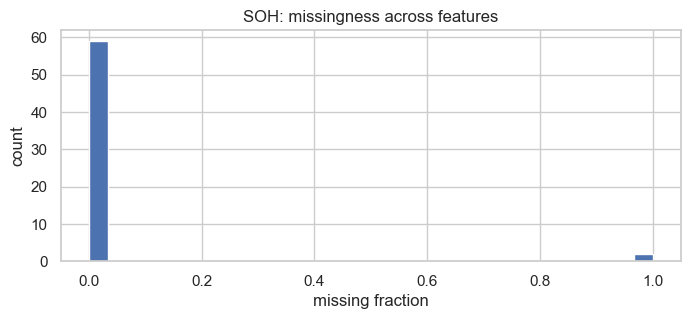

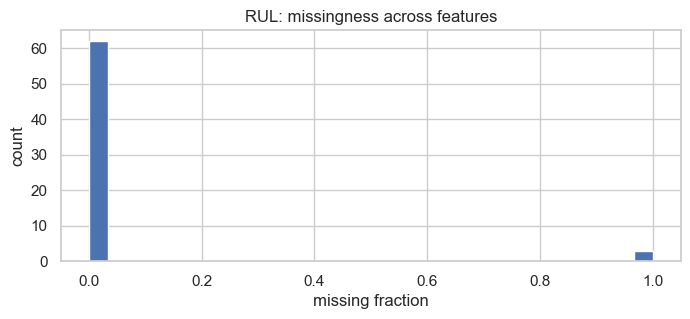

SOH correlation-dropped count: 21
RUL correlation-dropped count: 24


,n_features,worst_feature,worst_vif
0,38,i_dis_max,747.624627
1,37,temp_max,292.569339
2,36,frac_active_discharge,171.883813
3,35,chg_cv_time_s,83.099569
4,34,i_dis_mean,64.206589


,n_features,worst_feature,worst_vif
0,38,i_dis_max,780.784611
1,37,temp_max,279.168909
2,36,frac_active_discharge,141.442873
3,35,chg_cv_time_s,120.227772
4,34,i_dis_mean,53.664796


In [27]:
def plot_missingness(miss: pd.Series, title: str):
    plt.figure(figsize=(8, 3))
    plt.hist(miss.values, bins=30)
    plt.title(title)
    plt.xlabel("missing fraction")
    plt.ylabel("count")
    plt.show()

plot_missingness(unsup_soh["missing_frac"], "SOH: missingness across features")
plot_missingness(unsup_rul["missing_frac"], "RUL: missingness across features")

print("SOH correlation-dropped count:", len(unsup_soh["corr_dropped"]))
print("RUL correlation-dropped count:", len(unsup_rul["corr_dropped"]))

if not unsup_soh["vif_history"].empty:
    display(unsup_soh["vif_history"].head())
if not unsup_rul["vif_history"].empty:
    display(unsup_rul["vif_history"].head())

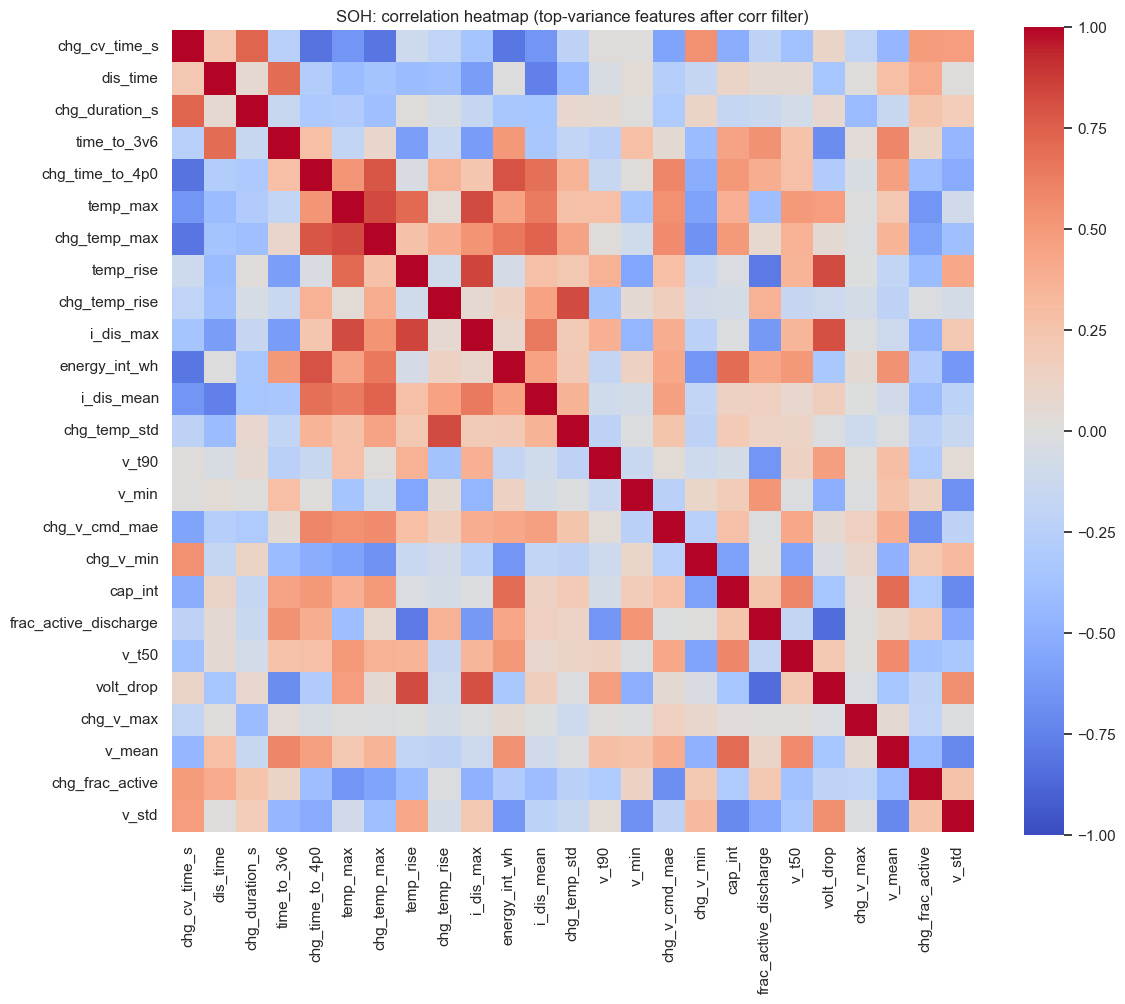

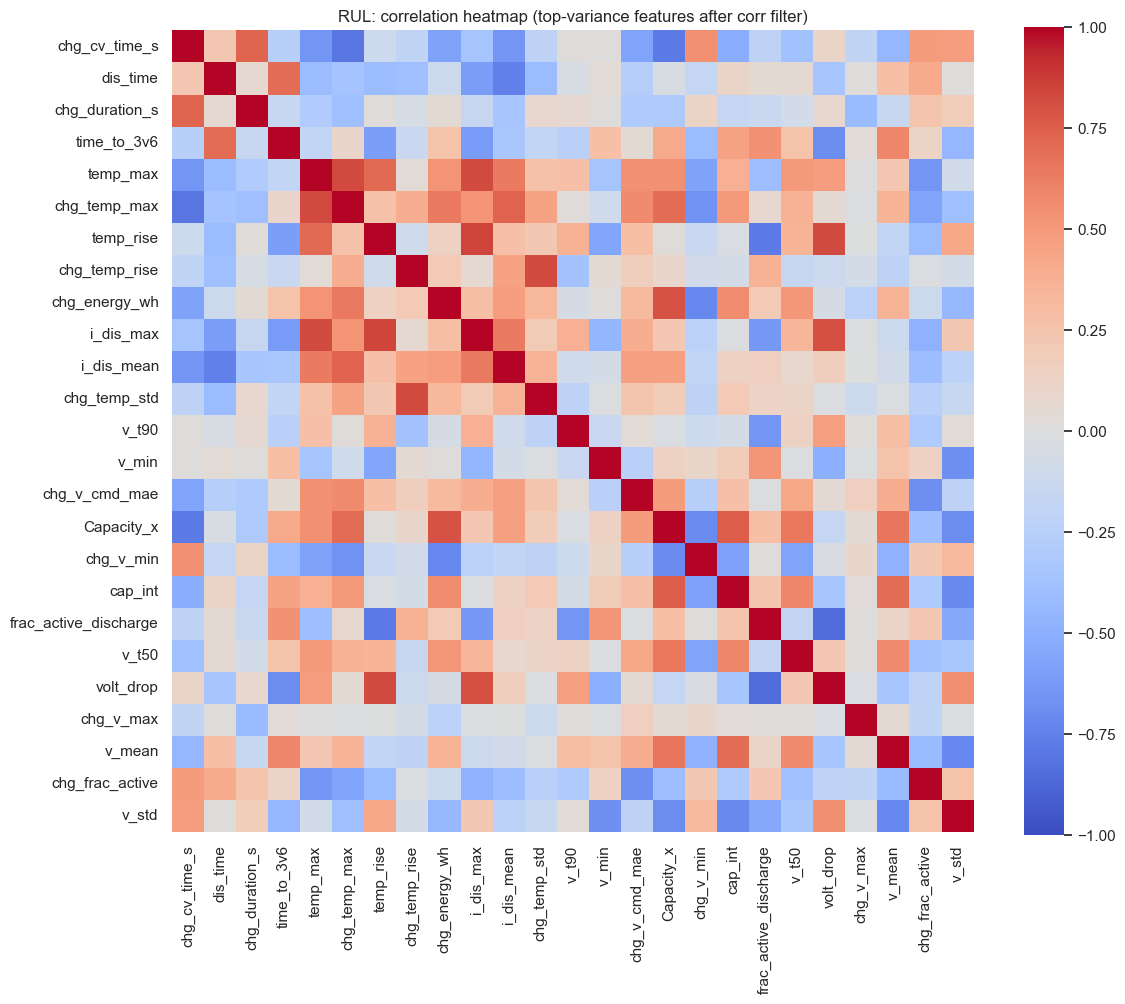

,feature,vif
9,i_dis_max,648.361202
11,i_dis_mean,320.751157
18,frac_active_discharge,269.780162
5,temp_max,240.998254
6,chg_temp_max,144.006313
0,chg_cv_time_s,83.612443
7,temp_rise,80.593165
20,volt_drop,40.635448
8,chg_temp_rise,36.007392
22,v_mean,31.197123


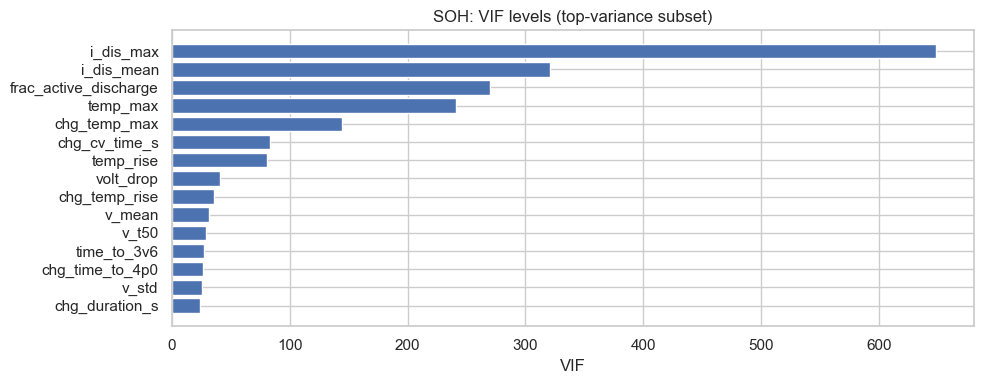

,feature,vif
9,i_dis_max,660.781435
10,i_dis_mean,305.391084
18,frac_active_discharge,281.080563
4,temp_max,230.727948
5,chg_temp_max,138.800938
0,chg_cv_time_s,90.650634
6,temp_rise,80.460641
20,volt_drop,51.105147
2,chg_duration_s,40.969750
15,Capacity_x,39.265042


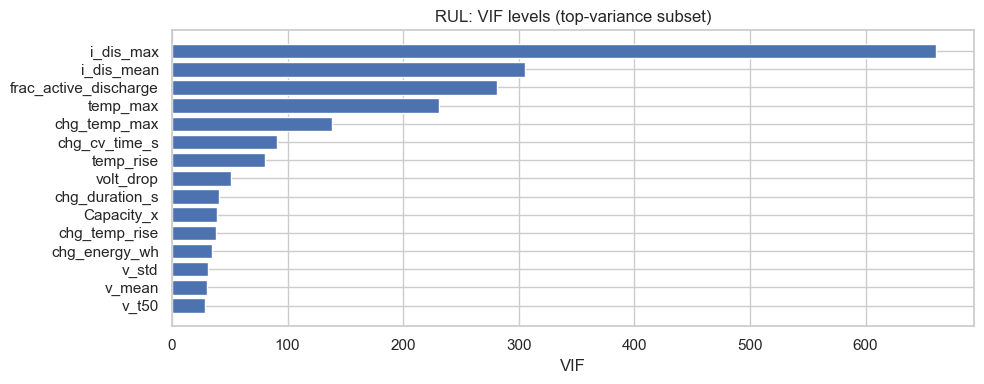

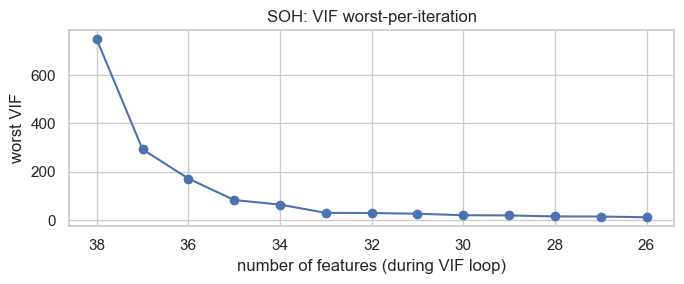

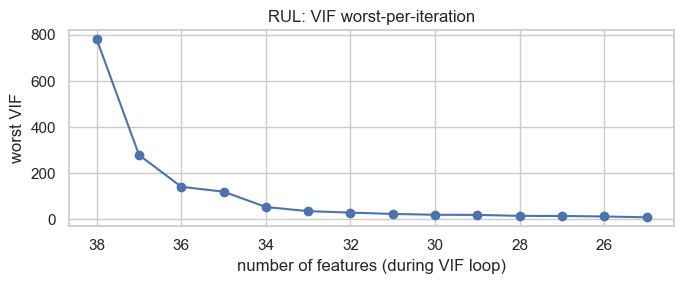

In [28]:
def _median_impute_frame(X: pd.DataFrame) -> pd.DataFrame:
    X_imp = X.copy()
    for c in X_imp.columns:
        X_imp[c] = X_imp[c].fillna(X_imp[c].median())
    return X_imp

def correlation_heatmap(X: pd.DataFrame, title: str, max_features: int = 25):
    """Plot a correlation heatmap for a manageable subset of features.

    The subset is chosen by highest variance after median imputation to keep the plot readable.
    """
    X_imp = _median_impute_frame(X)
    variances = X_imp.var().sort_values(ascending=False)
    cols = variances.head(min(max_features, len(variances))).index.tolist()
    if len(cols) < 2:
        print(f"{title}: not enough features for a correlation heatmap")
        return
    corr = X_imp[cols].corr().astype(float)

    plt.figure(figsize=(12, 10))
    if _HAS_SEABORN:
        sns.heatmap(corr, cmap="coolwarm", center=0.0, vmin=-1.0, vmax=1.0, square=True)
    else:
        plt.imshow(corr.values, cmap="coolwarm", vmin=-1.0, vmax=1.0)
        plt.colorbar(label="correlation")
        plt.xticks(range(len(cols)), cols, rotation=90)
        plt.yticks(range(len(cols)), cols)
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_top_vif(X: pd.DataFrame, title: str, max_features: int = 25, top_n: int = 15) -> pd.DataFrame:
    """Compute and plot VIF on a subset of features to control runtime."""
    X_imp = _median_impute_frame(X)
    variances = X_imp.var().sort_values(ascending=False)
    cols = variances.head(min(max_features, len(variances))).index.tolist()
    if len(cols) < 2:
        print(f"{title}: not enough features for VIF")
        return pd.DataFrame(columns=["feature", "vif"])
    vif_tbl = compute_vif_table(X_imp[cols]).head(top_n)
    display(vif_tbl)

    plt.figure(figsize=(10, 4))
    plt.barh(vif_tbl["feature"].iloc[::-1], vif_tbl["vif"].iloc[::-1])
    plt.xlabel("VIF")
    plt.title(title)
    plt.tight_layout()
    plt.show()
    return vif_tbl

def plot_vif_history(vif_hist: pd.DataFrame, title: str):
    if vif_hist is None or vif_hist.empty:
        print(f"{title}: no VIF drops performed")
        return
    plt.figure(figsize=(7, 3))
    plt.plot(vif_hist["n_features"], vif_hist["worst_vif"], marker="o")
    plt.gca().invert_xaxis()
    plt.xlabel("number of features (during VIF loop)")
    plt.ylabel("worst VIF")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Correlation heatmaps after correlation filtering (closest to the final unsupervised feature set)
correlation_heatmap(unsup_soh["X_after_corr"], "SOH: correlation heatmap (top-variance features after corr filter)")
correlation_heatmap(unsup_rul["X_after_corr"], "RUL: correlation heatmap (top-variance features after corr filter)")

# VIF diagnostics on a representative subset
_ = plot_top_vif(unsup_soh["X_after_corr"], "SOH: VIF levels (top-variance subset)")
_ = plot_top_vif(unsup_rul["X_after_corr"], "RUL: VIF levels (top-variance subset)")

# VIF loop history (worst VIF per iteration)
plot_vif_history(unsup_soh["vif_history"], "SOH: VIF worst-per-iteration")
plot_vif_history(unsup_rul["vif_history"], "RUL: VIF worst-per-iteration")

## 4) Supervised feature selection
Supervised methods use $(X, y)$ and produce a relevance signal for a specific target. The goal is not only to find a small set of features, but to obtain **multiple, complementary views** of what is useful under group-aware splitting.

### Signals used in this notebook

#### A) Filter methods (fast, model-free)
- **Mutual information (MI)**: estimates a non-linear dependency between a feature and the target. MI is not limited to linear relationships, but it can be noisy with small sample sizes and correlated features.
- **Univariate F-test (`f_regression`)**: measures linear association between each feature and the target independently. It is simple and interpretable but can undervalue features that matter only through interactions.

Both filters are computed fold-wise on GroupKFold training splits and then averaged to reduce bias.

#### B) Embedded methods (selection happens during model training)
- **Lasso / ElasticNet**: linear models with $\ell_1$ (or combined $\ell_1 + \ell_2$) regularization. Coefficients can be shrunk to exactly zero, yielding sparsity. These methods can be unstable under strong multicollinearity, which is one reason the unsupervised redundancy reduction is applied first.
- **Tree ensembles**: models such as ExtraTrees can capture non-linearities and feature interactions. They can also assign importance measures, but raw impurity-based importance can be biased toward high-cardinality / high-variance features.

#### C) Model-agnostic importance
- **Permutation importance**: measures the drop in a chosen metric when a feature is randomly permuted, breaking its association with the target. This is computed fold-wise and averaged. Permutation importance is slower but is often more faithful than impurity-based scores.

#### D) Wrapper methods (search using a predictive model)
- **RFE (Recursive Feature Elimination/ Backword selection)**: repeatedly fits a model and removes the least important features until a target feature count is reached. RFE can yield strong subsets but is computationally expensive; therefore it is run only on a candidate set formed from filter rankings.

### Why group-aware splitting matters here
All supervised signals are computed with `GroupKFold` using `battery_id` groups. This prevents cycles from the same battery appearing in both train and test folds, which would otherwise inflate scores and bias feature rankings.

In [29]:
def make_preprocessor(feature_names: list[str]) -> ColumnTransformer:
    return ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]), feature_names),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )

def cv_regression_report(X: pd.DataFrame, y: pd.Series, groups: pd.Series, estimator, n_splits: int, label: str) -> pd.DataFrame:
    gkf = GroupKFold(n_splits=n_splits)
    rows = []
    for fold, (tr, te) in enumerate(gkf.split(X, y, groups), start=1):
        Xtr, Xte = X.iloc[tr], X.iloc[te]
        ytr, yte = y.iloc[tr], y.iloc[te]
        est = estimator
        est.fit(Xtr, ytr)
        pred = est.predict(Xte)
        rows.append({
            "label": label,
            "fold": fold,
            "mae": float(mean_absolute_error(yte, pred)),
            "rmse": float(np.sqrt(mean_squared_error(yte, pred))),
            "r2": float(r2_score(yte, pred)),
        })
    return pd.DataFrame(rows)

def ranked_filter_scores(X: pd.DataFrame, y: pd.Series, groups: pd.Series, n_splits: int) -> pd.DataFrame:
    # Fold-wise scoring to reduce group leakage
    gkf = GroupKFold(n_splits=n_splits)
    feats = list(X.columns)
    mi_scores = np.zeros(len(feats), dtype=float)
    f_scores = np.zeros(len(feats), dtype=float)

    for tr, _ in gkf.split(X, y, groups):
        Xtr = X.iloc[tr]
        ytr = y.iloc[tr]
        # Median imputation for filter methods
        Xtr_imp = Xtr.copy()
        for c in Xtr_imp.columns:
            Xtr_imp[c] = Xtr_imp[c].fillna(Xtr_imp[c].median())
        mi = mutual_info_regression(Xtr_imp, ytr, random_state=42)
        f, _ = f_regression(Xtr_imp, ytr)
        mi_scores += np.nan_to_num(mi)
        f_scores += np.nan_to_num(f)

    mi_scores /= n_splits
    f_scores /= n_splits

    out = pd.DataFrame({"feature": feats, "mi": mi_scores, "f": f_scores})
    out = out.sort_values(["mi", "f"], ascending=False)
    return out

In [30]:
X_soh_u = unsup_soh["X_reduced"]
X_rul_u = unsup_rul["X_reduced"]

rank_soh = ranked_filter_scores(X_soh_u, y_soh, g_soh, n_splits_soh)
rank_rul = ranked_filter_scores(X_rul_u, y_rul, g_rul, n_splits_rul)

print("Top SOH (filter):")
display(rank_soh.head(15))
print("Top RUL (filter):")
display(rank_rul.head(15))

Top SOH (filter):


,feature,mi,f
18,energy_int_wh,1.670623,977.287225
16,time_to_3v6,1.180521,7.760245
23,v_t50,1.109163,207.619533
0,Rct_imp,0.991031,346.429588
9,chg_v_mean,0.967175,890.885622
24,v_t90,0.916767,11.678555
1,Re_imp,0.897834,19.879473
21,v_mean,0.838164,29.615685
25,dvdt_mean,0.829248,454.745432
15,dvdt_std,0.800516,53.281644


Top RUL (filter):


,feature,mi,f
0,Rct_imp,1.154829,311.874175
1,Re_imp,1.117077,95.285505
7,chg_duration_s,1.003024,1.039951
5,chg_energy_wh,0.861969,458.043911
21,v_mean,0.781778,362.357551
23,v_t50,0.770617,236.463504
17,time_to_3v6,0.760491,53.160239
9,chg_v_mean,0.746604,575.463523
16,dvdt_mean,0.624462,2.334582
24,v_t90,0.612895,53.961965


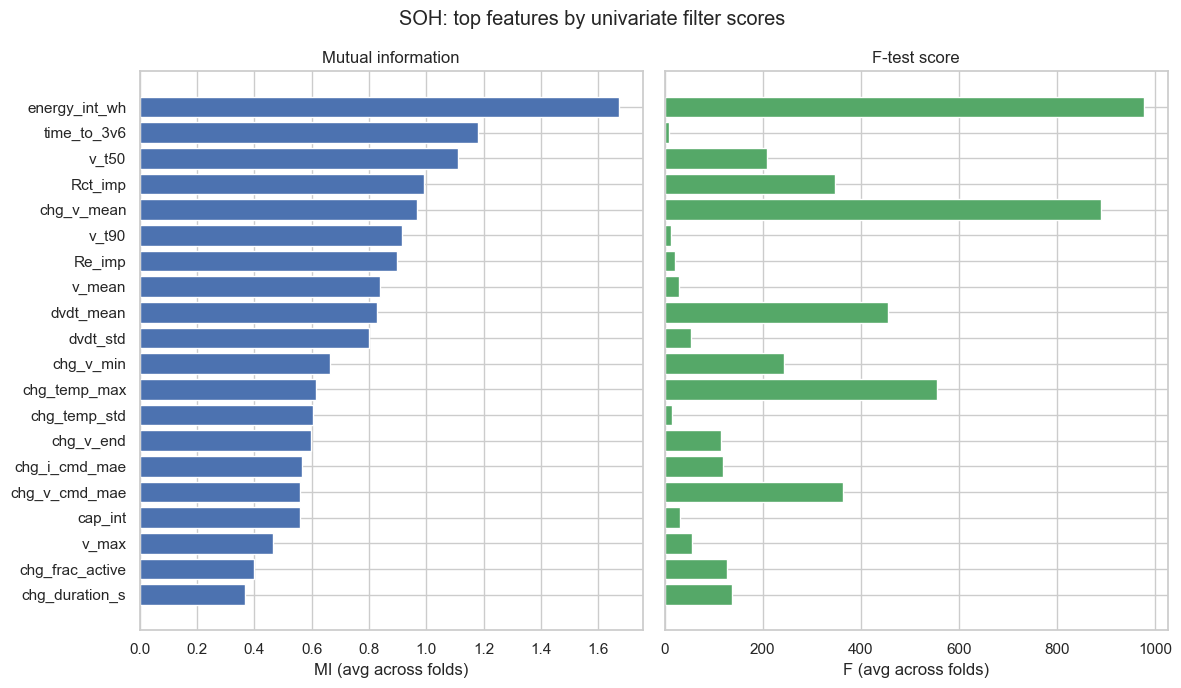

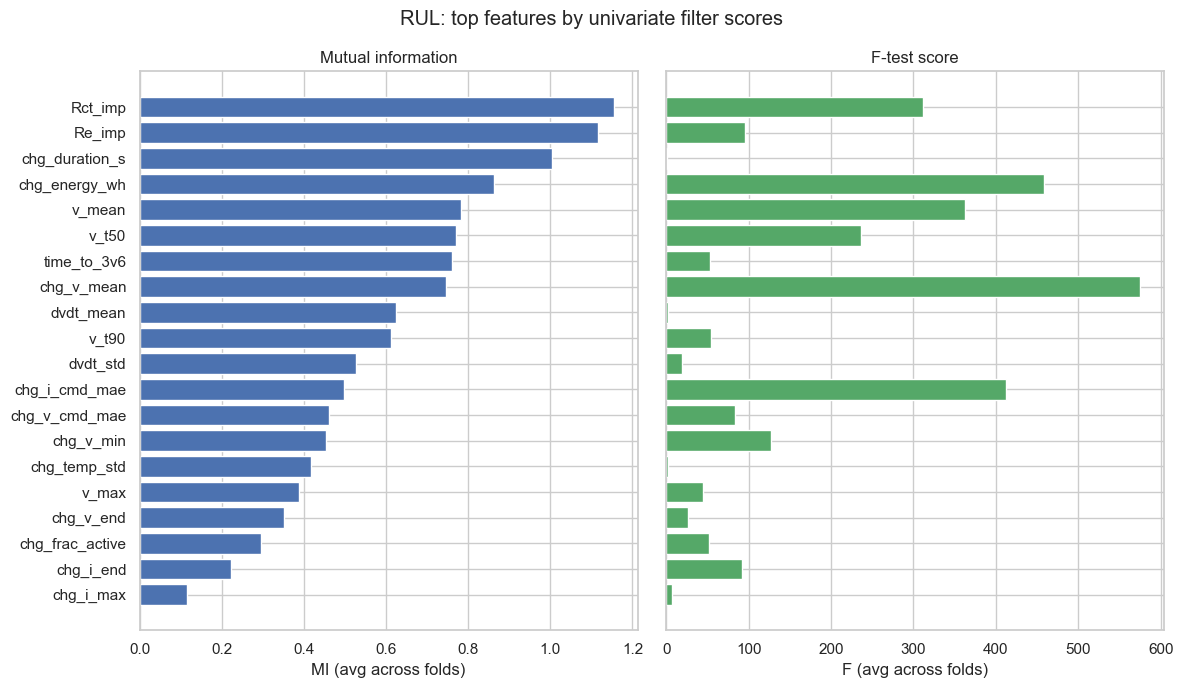

In [31]:
def plot_top_filter_scores(rank_df: pd.DataFrame, title: str, top_n: int = 20):
    top = rank_df.head(top_n).copy()
    top = top.sort_values("mi", ascending=True)
    fig, ax = plt.subplots(1, 2, figsize=(12, max(4, 0.25 * len(top) + 2)), sharey=True)
    ax[0].barh(top["feature"], top["mi"], color="#4C72B0")
    ax[0].set_title("Mutual information")
    ax[0].set_xlabel("MI (avg across folds)")
    ax[1].barh(top["feature"], top["f"], color="#55A868")
    ax[1].set_title("F-test score")
    ax[1].set_xlabel("F (avg across folds)")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_top_filter_scores(rank_soh, "SOH: top features by univariate filter scores")
plot_top_filter_scores(rank_rul, "RUL: top features by univariate filter scores")

### Embedded selection: Lasso / ElasticNet
L1-regularized linear models provide an embedded selection mechanism: they fit a predictive model while shrinking some coefficients to exactly zero.

- **What the coefficient means**: after standardization, the magnitude of a coefficient reflects the strength of a linear association under the model assumptions.
- **Why this helps**: sparsity can improve interpretability and reduce variance when many correlated predictors exist.
- **Important limitation**: when strong collinearity remains, Lasso can arbitrarily choose one feature from a correlated set. This is why the earlier correlation/VIF reduction is useful.

The cross-validation inside Lasso/ElasticNet is performed on group-aware splits so that regularization strength is tuned without mixing cycles from the same battery across folds.

In [32]:
def lasso_select_features(X: pd.DataFrame, y: pd.Series, groups: pd.Series, n_splits: int, model: str = "lasso") -> tuple[pd.Series, Pipeline]:
    feats = list(X.columns)
    gkf = GroupKFold(n_splits=n_splits)

    if model == "lasso":
        reg = LassoCV(cv=list(gkf.split(X, y, groups)), random_state=42, max_iter=20000)
    else:
        reg = ElasticNetCV(l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95], cv=list(gkf.split(X, y, groups)), random_state=42, max_iter=20000)

    pipe = Pipeline([
        ("prep", make_preprocessor(feats)),
        ("reg", reg),
    ])
    pipe.fit(X, y)

    coef = pipe.named_steps["reg"].coef_
    coef_s = pd.Series(coef, index=feats).sort_values(key=lambda s: np.abs(s), ascending=False)
    return coef_s, pipe

coef_soh, lasso_soh_model = lasso_select_features(X_soh_u, y_soh, g_soh, n_splits_soh, model="lasso")
coef_rul, lasso_rul_model = lasso_select_features(X_rul_u, y_rul, g_rul, n_splits_rul, model="lasso")

print("SOH non-zero coef count:", int((coef_soh != 0).sum()))
print("RUL non-zero coef count:", int((coef_rul != 0).sum()))

display(coef_soh.head(20))
display(coef_rul.head(20))

SOH non-zero coef count: 19
RUL non-zero coef count: 23


energy_int_wh      0.110181
cap_int           -0.096473
dvdt_std           0.032690
dvdt_mean         -0.026373
v_t50              0.025601
v_min              0.017158
v_mean             0.017075
chg_v_min         -0.008008
time_to_3v6       -0.008000
v_max             -0.007088
chg_i_max         -0.005961
chg_temp_std      -0.004683
Re_imp             0.003655
chg_frac_active    0.002734
v_t90              0.002083
chg_v_end         -0.001363
chg_i_end         -0.000918
chg_duration_s     0.000907
Rct_imp            0.000212
chg_v_cmd_mae     -0.000000
dtype: float64

chg_v_mean        -72.372449
dvdt_std          -72.089801
chg_v_min          65.162639
dvdt_mean          60.944511
chg_energy_wh      51.609063
Rct_imp           -40.947543
time_to_3v6       -40.831997
v_min             -40.349849
chg_i_cmd_mae      27.981983
chg_v_max          27.924771
Re_imp             26.875638
v_mean             22.988727
chg_temp_std      -20.011553
chg_duration_s     16.003897
v_t50              14.707923
chg_frac_active    13.592019
i_dis_min          12.083359
v_t90              11.268082
chg_i_max          -7.017305
v_max               5.216560
dtype: float64

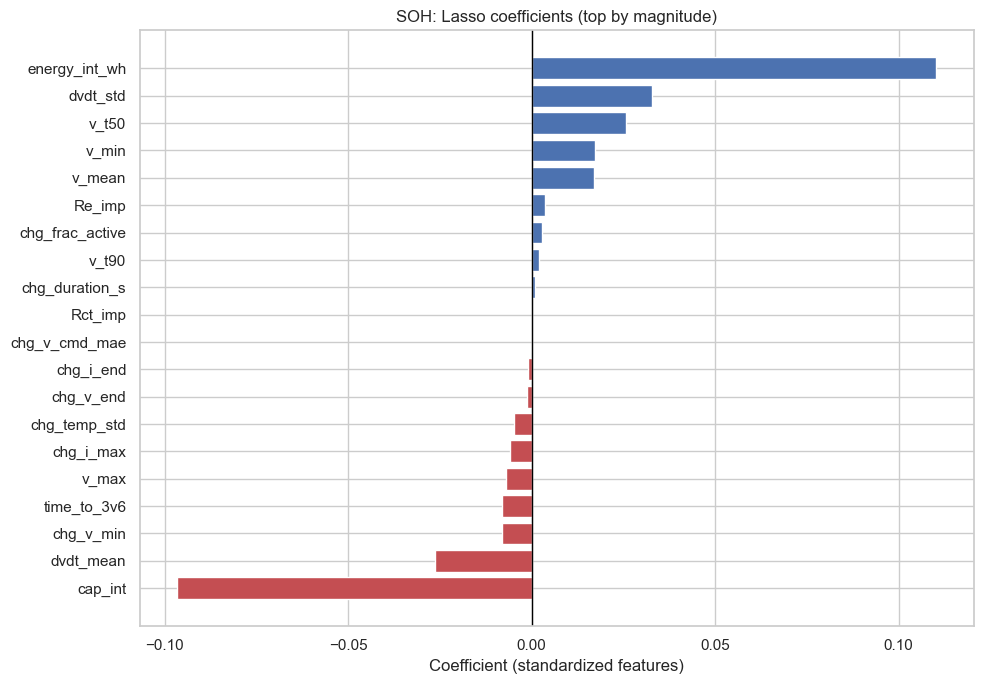

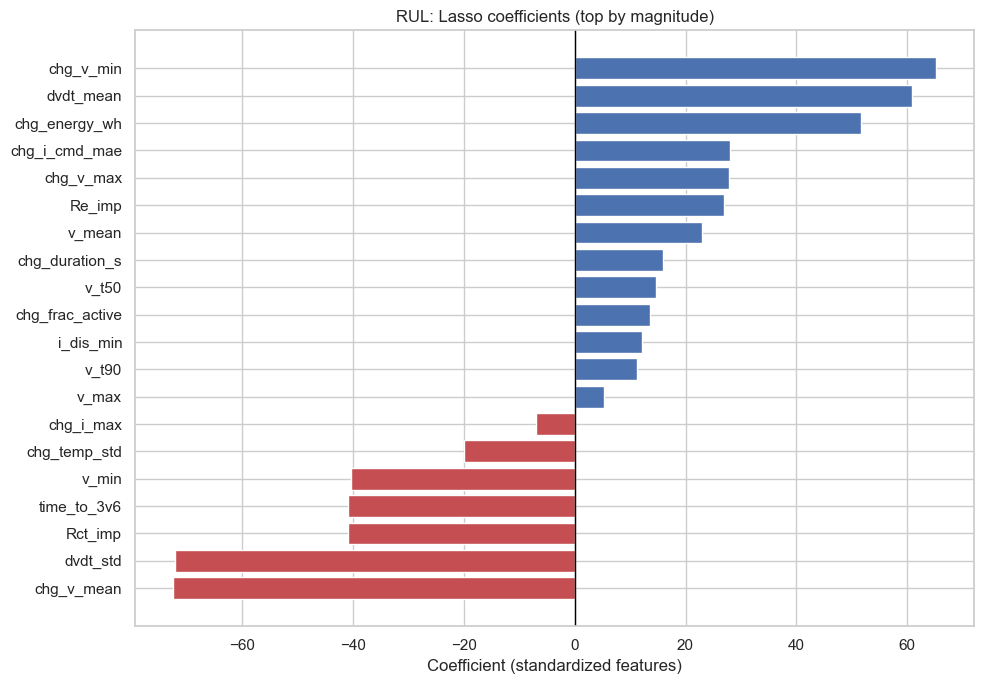

In [33]:
def plot_top_coefficients(coef: pd.Series, title: str, top_n: int = 20):
    top = coef.copy()
    top = top.reindex(top.abs().sort_values(ascending=False).head(top_n).index)
    top = top.sort_values()
    plt.figure(figsize=(10, max(4, 0.25 * len(top) + 2)))
    colors = ["#C44E52" if v < 0 else "#4C72B0" for v in top.values]
    plt.barh(top.index, top.values, color=colors)
    plt.axvline(0.0, color="black", linewidth=1)
    plt.xlabel("Coefficient (standardized features)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_top_coefficients(coef_soh, "SOH: Lasso coefficients (top by magnitude)")
plot_top_coefficients(coef_rul, "RUL: Lasso coefficients (top by magnitude)")

### Embedded + model-agnostic importance: trees + permutation importance
Tree ensembles (e.g., ExtraTrees) can capture non-linear relationships and feature interactions without explicit feature engineering for interactions.

Permutation importance is used as the primary importance signal in this notebook because it is closer to a causal "usefulness" check than impurity-based importances: it measures how much predictive performance degrades when a feature is shuffled.

- **Metric**: negative MAE is used for scoring; a larger value means that permuting the feature harms performance more (feature is more useful).
- **Fold-wise averaging**: importance is computed per GroupKFold fold and then averaged to reduce sensitivity to any single battery split.
- **Caveat**: when features are strongly correlated, permutation importance can distribute credit across the correlated set; a low importance does not necessarily mean the feature is irrelevant.

In [34]:
def permutation_importance_cv(X: pd.DataFrame, y: pd.Series, groups: pd.Series, n_splits: int, random_state: int = 42) -> pd.Series:
    feats = list(X.columns)
    gkf = GroupKFold(n_splits=n_splits)

    base_est = ExtraTreesRegressor(
        n_estimators=400,
        random_state=random_state,
        n_jobs=-1,
    )

    pipe = Pipeline([
        ("prep", make_preprocessor(feats)),
        ("est", base_est),
    ])

    importances = np.zeros(len(feats), dtype=float)

    for tr, te in gkf.split(X, y, groups):
        Xtr, Xte = X.iloc[tr], X.iloc[te]
        ytr, yte = y.iloc[tr], y.iloc[te]
        pipe.fit(Xtr, ytr)
        r = permutation_importance(pipe, Xte, yte, n_repeats=8, random_state=random_state, scoring="neg_mean_absolute_error")
        importances += r.importances_mean

    importances /= n_splits
    return pd.Series(importances, index=feats).sort_values(ascending=False)

perm_soh = permutation_importance_cv(X_soh_u, y_soh, g_soh, n_splits_soh)
perm_rul = permutation_importance_cv(X_rul_u, y_rul, g_rul, n_splits_rul)

print("Top SOH (perm):")
display(perm_soh.head(15))
print("Top RUL (perm):")
display(perm_rul.head(15))

Top SOH (perm):


energy_int_wh    0.023828
chg_v_mean       0.009562
cap_int          0.007807
chg_temp_max     0.004687
time_to_3v6      0.004150
Rct_imp          0.002655
v_t50            0.002160
Re_imp           0.001853
dvdt_std         0.000945
chg_v_cmd_mae    0.000920
v_t90            0.000898
v_mean           0.000740
chg_i_end        0.000719
chg_v_end        0.000598
chg_temp_std     0.000536
dtype: float64

Top RUL (perm):


chg_energy_wh      9.268581
chg_v_mean         8.065026
chg_duration_s     5.369001
v_t50              3.651679
time_to_3v6        3.034986
v_mean             2.201888
cap_int            2.014538
v_t90              1.928245
Rct_imp            1.719093
dvdt_mean          1.356741
dvdt_std           1.121851
chg_v_min          0.594690
chg_frac_active    0.418624
Re_imp             0.415608
chg_temp_std       0.337449
dtype: float64

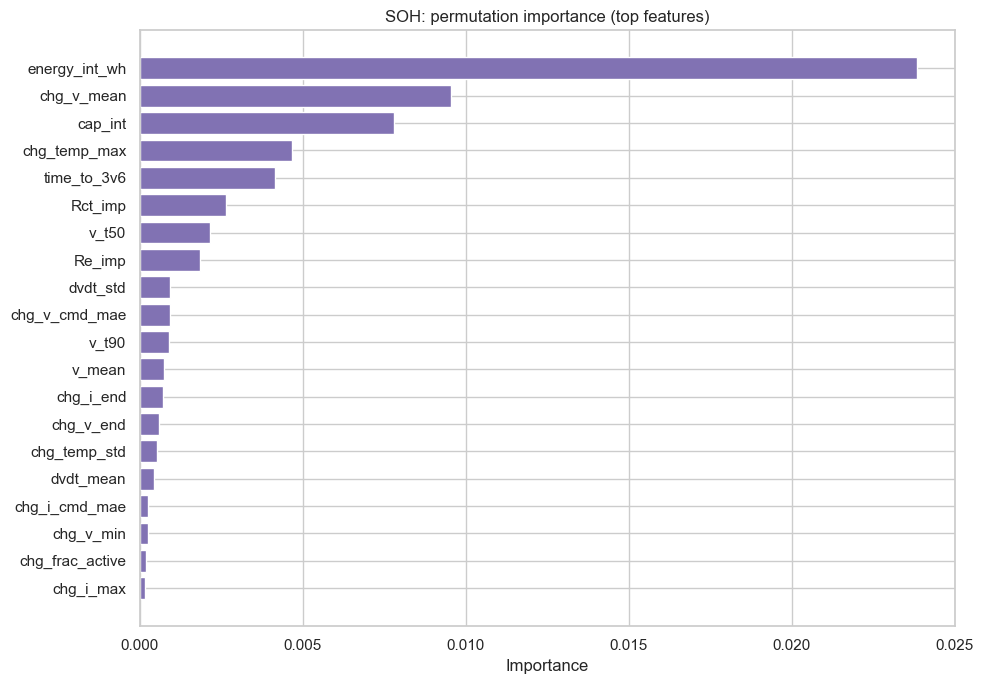

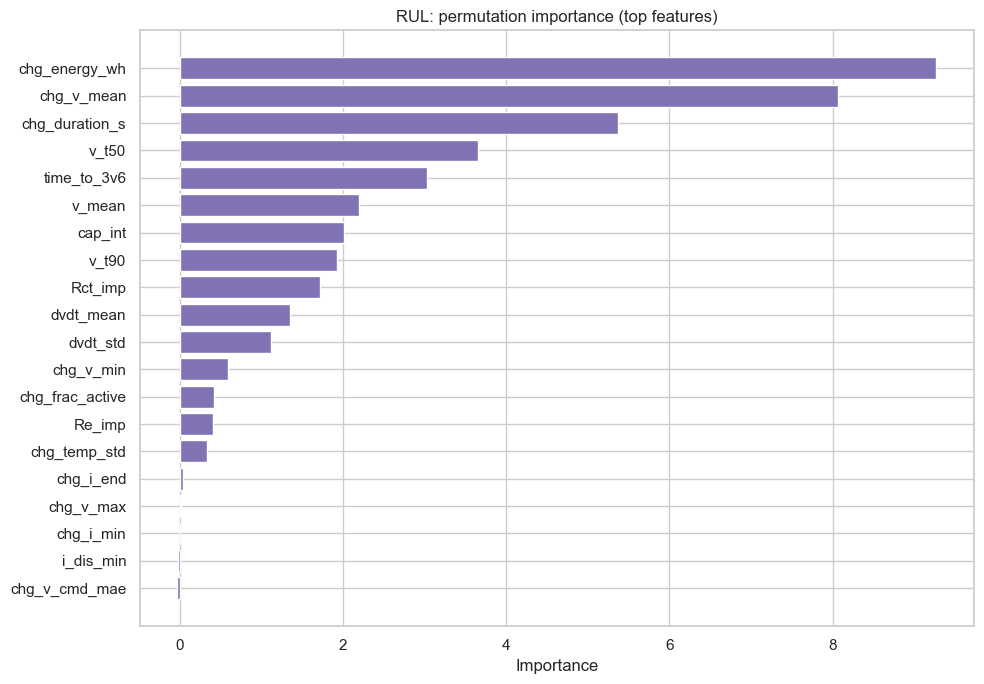

In [35]:
def plot_top_series(s: pd.Series, title: str, top_n: int = 20, color: str = "#4C72B0"):
    top = s.head(top_n).iloc[::-1]
    plt.figure(figsize=(10, max(4, 0.25 * len(top) + 2)))
    plt.barh(top.index, top.values, color=color)
    plt.xlabel("Importance")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_top_series(perm_soh, "SOH: permutation importance (top features)", top_n=20, color="#8172B3")
plot_top_series(perm_rul, "RUL: permutation importance (top features)", top_n=20, color="#8172B3")

### Wrapper method: RFE on a candidate subset
Recursive Feature Elimination (RFE) is a wrapper method: it uses a predictive model repeatedly to decide which features to keep.

- **Procedure**: fit the model, rank features by model importance (here, coefficient magnitude from Ridge), remove the weakest features, and repeat until the desired subset size is reached.
- **Why Ridge**: Ridge regression tends to be more stable under multicollinearity than unregularized linear regression, making the elimination path less noisy.
- **Runtime**: RFE scales poorly with feature count. To control cost, a two-stage strategy is used:
  1) Use filter ranking to form a candidate set (top-k)
  2) Run RFE on that candidate set

RFE produces one compact subset per target, which is later combined with other signals to reduce reliance on a single method.

In [36]:
def rfe_select(X: pd.DataFrame, y: pd.Series, top_rank: pd.DataFrame, top_k: int, n_features_to_select: int) -> list[str]:
    cand = top_rank.head(top_k)["feature"].tolist()
    cand = [c for c in cand if c in X.columns]
    Xc = X.loc[:, cand].copy()

    feats = list(Xc.columns)
    prep = make_preprocessor(feats)
    base = Ridge(alpha=1.0)

    # RFE expects dense arrays
    Xc_t = prep.fit_transform(Xc)
    rfe = RFE(estimator=base, n_features_to_select=min(n_features_to_select, Xc_t.shape[1]), step=0.1)
    rfe.fit(Xc_t, y)

    selected = [f for f, m in zip(feats, rfe.support_) if bool(m)]
    return selected

rfe_soh = rfe_select(X_soh_u, y_soh, rank_soh, top_k=CFG.top_k_filter, n_features_to_select=CFG.rfe_n_features)
rfe_rul = rfe_select(X_rul_u, y_rul, rank_rul, top_k=CFG.top_k_filter, n_features_to_select=CFG.rfe_n_features)

print("RFE selected (SOH):", len(rfe_soh))
print(rfe_soh)
print("RFE selected (RUL):", len(rfe_rul))
print(rfe_rul)

RFE selected (SOH): 25
['energy_int_wh', 'time_to_3v6', 'v_t50', 'Rct_imp', 'chg_v_mean', 'v_t90', 'Re_imp', 'v_mean', 'dvdt_mean', 'dvdt_std', 'chg_v_min', 'chg_temp_max', 'chg_temp_std', 'chg_v_end', 'chg_i_cmd_mae', 'chg_v_cmd_mae', 'cap_int', 'v_max', 'chg_frac_active', 'chg_duration_s', 'chg_i_end', 'chg_i_max', 'v_min', 'chg_v_max', 'i_dis_min']
RFE selected (RUL): 25
['Rct_imp', 'Re_imp', 'chg_duration_s', 'chg_energy_wh', 'v_mean', 'v_t50', 'time_to_3v6', 'chg_v_mean', 'dvdt_mean', 'v_t90', 'dvdt_std', 'chg_i_cmd_mae', 'chg_v_cmd_mae', 'chg_v_min', 'chg_temp_std', 'v_max', 'chg_v_end', 'chg_frac_active', 'chg_i_end', 'chg_i_max', 'cap_int', 'v_min', 'chg_i_min', 'i_dis_min', 'chg_v_max']


## 5) Features eliminated by each method
This section summarizes the columns removed at each unsupervised step and the features not selected by each supervised selector. The aim is traceability: it becomes clear which method removed which features and why.

In [37]:
def _sorted_list(items: Iterable[str]) -> list[str]:
    return sorted({str(x) for x in items})

def _diff(a: Iterable[str], b: Iterable[str]) -> list[str]:
    return _sorted_list(set(a) - set(b))

def _export_eliminated(eliminated_map: dict[str, list[str]], out_path: Path) -> pd.DataFrame:
    rows = []
    for method, feats in eliminated_map.items():
        for f in feats:
            rows.append({"method": method, "feature": f})
    out = pd.DataFrame(rows).sort_values(["method", "feature"]).reset_index(drop=True)
    out.to_csv(out_path, index=False)
    return out

def eliminated_unsupervised(X_raw: pd.DataFrame, unsup: dict) -> dict[str, list[str]]:
    raw = list(X_raw.columns)
    after_missing = list(unsup["X_after_missing"].columns)
    after_const = list(unsup["X_after_constant"].columns)
    after_var = list(unsup["X_after_variance"].columns)
    after_corr = list(unsup["X_after_corr"].columns)
    reduced = list(unsup["X_reduced"].columns)

    eliminated = {
        "unsup_missingness": _diff(raw, after_missing),
        "unsup_constant": _diff(after_missing, after_const),
        "unsup_zero_variance": _diff(after_const, after_var),
        "unsup_correlation": _sorted_list(unsup.get("corr_dropped", [])),
        "unsup_vif": _diff(after_corr, reduced),
    }
    return eliminated

def eliminated_supervised(
    X_u: pd.DataFrame,
    rank: pd.DataFrame,
    coef: pd.Series,
    perm: pd.Series,
    rfe_selected: list[str],
    cfg: SelectionConfig,
) -> dict[str, list[str]]:
    feats = list(X_u.columns)

    # Filter selectors need a cutoff to become a "selection"; top_k_filter is used here for traceability
    keep_filter = set(rank.head(cfg.top_k_filter)["feature"].tolist())
    keep_filter = {f for f in keep_filter if f in feats}

    keep_lasso = set(coef[coef != 0].index.tolist())
    keep_perm = set(perm.head(cfg.top_k_filter).index.tolist())

    # RFE operates on a candidate subset formed from filter ranking
    cand = [f for f in rank.head(cfg.top_k_filter)["feature"].tolist() if f in feats]
    rfe_sel = {f for f in rfe_selected if f in feats}

    eliminated = {
        f"filter_not_in_top_{cfg.top_k_filter}": _diff(feats, keep_filter),
        "lasso_zero_coef": _diff(feats, keep_lasso),
        f"perm_not_in_top_{cfg.top_k_filter}": _diff(feats, keep_perm),
        "rfe_eliminated_within_candidate": _diff(cand, rfe_sel),
        "rfe_not_considered_outside_candidate": _diff(feats, cand),
    }
    return eliminated

def _consolidate_like(
    X_u: pd.DataFrame,
    rank: pd.DataFrame,
    perm: pd.Series,
    rfe_list: list[str],
    extra_top: int = 12,
) -> list[str]:
    """Replicate the later consolidation logic so this cell can run standalone.

    This avoids a NameError if the consolidation cell has not executed yet.
    """
    top_rank = [f for f in rank.head(extra_top)["feature"].tolist() if f in X_u.columns]
    top_perm = [f for f in perm.head(extra_top).index.tolist() if f in X_u.columns]
    return list(dict.fromkeys(list(rfe_list) + top_rank + top_perm))

# Ensure final feature lists exist for traceability
if "final_soh" not in globals():
    final_soh = _consolidate_like(X_soh_u, rank_soh, perm_soh, rfe_soh, extra_top=12)

if "final_rul" not in globals():
    final_rul = _consolidate_like(X_rul_u, rank_rul, perm_rul, rfe_rul, extra_top=12)

# Build elimination maps for each target
elim_soh = {}
elim_soh.update(eliminated_unsupervised(X_soh, unsup_soh))
elim_soh.update(eliminated_supervised(X_soh_u, rank_soh, coef_soh, perm_soh, rfe_soh, CFG))
elim_soh["final_not_selected"] = _diff(X_soh_u.columns, final_soh)

elim_rul = {}
elim_rul.update(eliminated_unsupervised(X_rul, unsup_rul))
elim_rul.update(eliminated_supervised(X_rul_u, rank_rul, coef_rul, perm_rul, rfe_rul, CFG))
elim_rul["final_not_selected"] = _diff(X_rul_u.columns, final_rul)

# Summary tables (counts only)
def _counts_table(elim_map: dict[str, list[str]], target: str) -> pd.DataFrame:
    return pd.DataFrame({
        "target": target,
        "method": list(elim_map.keys()),
        "n_eliminated": [len(v) for v in elim_map.values()],
    }).sort_values(["n_eliminated", "method"], ascending=[False, True]).reset_index(drop=True)

display(_counts_table(elim_soh, "SOH"))
display(_counts_table(elim_rul, "RUL"))

# Preview a few eliminated features for each method
def _preview(elim_map: dict[str, list[str]], max_show: int = 25):
    for method, feats in elim_map.items():
        show = feats[:max_show]
        print(f"{method}: {len(feats)}")
        if len(show) > 0:
            print("  ", ", ".join(show))
        if len(feats) > max_show:
            print(f"  ... ({len(feats) - max_show} more)")
        print()

print("SOH eliminated feature previews")
_preview(elim_soh)
print("RUL eliminated feature previews")
_preview(elim_rul)

# Export full eliminated lists
out_elim_soh = OUT_DIR / "eliminated_features_soh.csv"
out_elim_rul = OUT_DIR / "eliminated_features_rul.csv"
_export_eliminated(elim_soh, out_elim_soh)
_export_eliminated(elim_rul, out_elim_rul)
print("Exported:", out_elim_soh)
print("Exported:", out_elim_rul)


,target,method,n_eliminated
0,SOH,unsup_correlation,21
1,SOH,unsup_vif,12
2,SOH,lasso_zero_coef,7
3,SOH,unsup_missingness,2
4,SOH,final_not_selected,1
5,SOH,rfe_eliminated_within_candidate,1
6,SOH,filter_not_in_top_40,0
7,SOH,perm_not_in_top_40,0
8,SOH,rfe_not_considered_outside_candidate,0
9,SOH,unsup_constant,0


,target,method,n_eliminated
0,RUL,unsup_correlation,24
1,RUL,unsup_vif,13
2,RUL,unsup_missingness,3
3,RUL,lasso_zero_coef,2
4,RUL,filter_not_in_top_40,0
5,RUL,final_not_selected,0
6,RUL,perm_not_in_top_40,0
7,RUL,rfe_eliminated_within_candidate,0
8,RUL,rfe_not_considered_outside_candidate,0
9,RUL,unsup_constant,0


SOH eliminated feature previews
unsup_missingness: 2
   Rct_chg, Re_chg

unsup_constant: 0

unsup_zero_variance: 0

unsup_correlation: 21
   ambient_temperature, ambient_temperature_chg, chg_energy_wh, chg_i_mean, chg_i_std, chg_q_ah, chg_temp_mean, chg_temp_min, chg_time_to_4p2, chg_v_std, duration_s, dvdt_max, dvdt_min, i_dis_std, r0_ohm, temp_mean, temp_min, temp_std, time_to_3v8, v_t10, volt_at_600s

unsup_vif: 12
   chg_cv_time_s, chg_temp_rise, chg_time_to_4p0, dis_time, frac_active_discharge, i_dis_max, i_dis_mean, temp_max, temp_rise, temp_slope, v_std, volt_drop

filter_not_in_top_40: 0

lasso_zero_coef: 7
   chg_i_cmd_mae, chg_i_min, chg_temp_max, chg_v_cmd_mae, chg_v_max, chg_v_mean, i_dis_min

perm_not_in_top_40: 0

rfe_eliminated_within_candidate: 1
   chg_i_min

rfe_not_considered_outside_candidate: 0

final_not_selected: 1
   chg_i_min

RUL eliminated feature previews
unsup_missingness: 3
   Capacity_chg, Rct_chg, Re_chg

unsup_constant: 0

unsup_zero_variance: 0

unsup_

## 6) Consolidate selection signals and export
Multiple methods rarely agree perfectly. A practical approach is to:
- keep features selected by RFE
- add a small set of consistently high-ranked features (filter + permutation)

The next cells build final feature lists for SOH and RUL and export them into `processed_data/`.

In [38]:
def consolidate_features(X: pd.DataFrame, rank: pd.DataFrame, perm: pd.Series, rfe_list: list[str], extra_top: int = 10) -> list[str]:
    top_rank = [f for f in rank.head(extra_top)["feature"].tolist() if f in X.columns]
    top_perm = [f for f in perm.head(extra_top).index.tolist() if f in X.columns]
    final = list(dict.fromkeys(list(rfe_list) + top_rank + top_perm))
    return final

final_soh = consolidate_features(X_soh_u, rank_soh, perm_soh, rfe_soh, extra_top=12)
final_rul = consolidate_features(X_rul_u, rank_rul, perm_rul, rfe_rul, extra_top=12)

print("Final feature count (SOH):", len(final_soh))
print("Final feature count (RUL):", len(final_rul))

display(pd.DataFrame({
    "SOH_selected": pd.Series(final_soh),
    "RUL_selected": pd.Series(final_rul),
}))

Final feature count (SOH): 25
Final feature count (RUL): 25


,SOH_selected,RUL_selected
0,energy_int_wh,Rct_imp
1,time_to_3v6,Re_imp
2,v_t50,chg_duration_s
3,Rct_imp,chg_energy_wh
4,chg_v_mean,v_mean
5,v_t90,v_t50
6,Re_imp,time_to_3v6
7,v_mean,chg_v_mean
8,dvdt_mean,dvdt_mean
9,dvdt_std,v_t90


In [39]:
def baseline_model(features: list[str]) -> Pipeline:
    prep = make_preprocessor(features)
    est = ExtraTreesRegressor(n_estimators=600, random_state=42, n_jobs=-1)
    return Pipeline([("prep", prep), ("est", est)])

rep_soh_all = cv_regression_report(X_soh_u, y_soh, g_soh, baseline_model(list(X_soh_u.columns)), n_splits_soh, label="SOH_all_unsup")
rep_soh_sel = cv_regression_report(X_soh_u[final_soh], y_soh, g_soh, baseline_model(final_soh), n_splits_soh, label="SOH_selected")

rep_rul_all = cv_regression_report(X_rul_u, y_rul, g_rul, baseline_model(list(X_rul_u.columns)), n_splits_rul, label="RUL_all_unsup")
rep_rul_sel = cv_regression_report(X_rul_u[final_rul], y_rul, g_rul, baseline_model(final_rul), n_splits_rul, label="RUL_selected")

report = pd.concat([rep_soh_all, rep_soh_sel, rep_rul_all, rep_rul_sel], ignore_index=True)
display(report.groupby("label")[["mae", "rmse", "r2"]].mean().sort_values("mae"))

,mae,rmse,r2
label,,,
SOH_all_unsup,0.042022,0.055704,0.713570
SOH_selected,0.042775,0.056975,0.699196
RUL_selected,83.942466,102.384161,0.431734
RUL_all_unsup,84.418868,102.769746,0.428384


In [40]:
out_soh = OUT_DIR / "selected_features_soh.csv"
out_rul = OUT_DIR / "selected_features_rul.csv"

pd.Series(final_soh, name="feature").to_csv(out_soh, index=False)
pd.Series(final_rul, name="feature").to_csv(out_rul, index=False)

print("Saved:", out_soh)
print("Saved:", out_rul)

Saved: c:\Users\Noufel\Documents\GitHub\Battery-health-prediction\processed_data\selected_features_soh.csv
Saved: c:\Users\Noufel\Documents\GitHub\Battery-health-prediction\processed_data\selected_features_rul.csv


## Notes and extensions
- The strict leakage rule for SOH drops capacity-related columns. If a scenario assumes capacity is not observed directly, this is the appropriate configuration.
- For RUL, `Cycle` is excluded intentionally to avoid learning an index-based shortcut. If the goal is to forecast RUL as a function of cycle count only, a separate baseline can be created where `Cycle` is included.
- If selection stability across batteries is a priority, stability selection or repeated GroupKFold can be added and aggregated.